# Regression with Kernel Density Matrices

This notebook illustrates how to use [Kernel Density Matrices](https://github.com/fagonzalezo/kdm) for regression with the PyTorch port (`kdm` v2).


In [1]:
# Uncomment to install the required packages
# !pip install kdm-torch


In [2]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import kdm
from kdm.models import KDMRegressModel
from kdm.utils import dm_rbf_expectation, dm_rbf_loglik, dm_rbf_variance, pure2dm
from kdm.init import init_kdm_layer

torch.manual_seed(0)
np.random.seed(1)


We use a synthetic dataset and compare the KDM regressor against a Gaussian Process baseline.


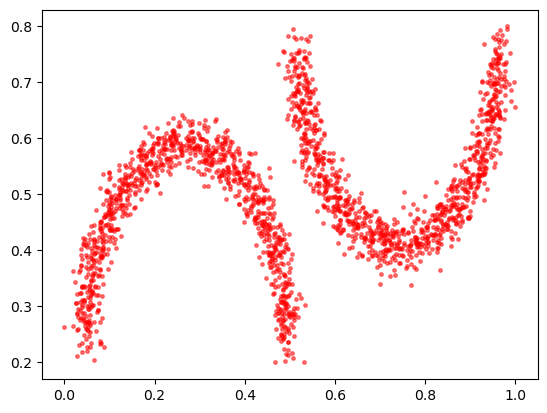

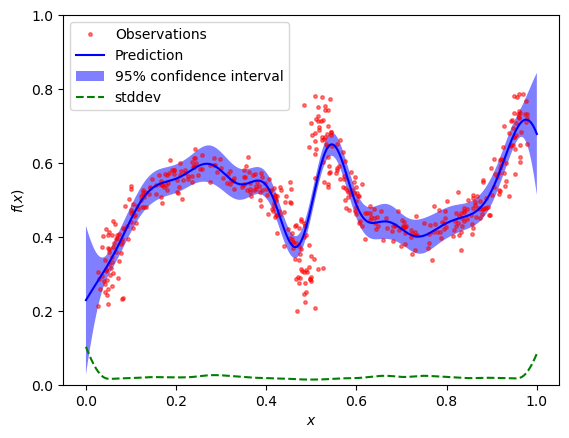

GP test MSE: 0.00469


In [3]:
num_train_samples = 500

X, y = make_moons(n_samples=2000, noise=0.07)
X[y == 1, 0] += 1.1
X[y == 1, 1] += 1
y = X[:, 1:]
X = X[:, :1]

scaler_x = MinMaxScaler((0, 1))
X = scaler_x.fit_transform(X)
scaler_y = MinMaxScaler((0.2, 0.8))
y = scaler_y.fit_transform(y)

plt.plot(X, y, 'r.', markersize=5, label='Observations', alpha=0.5)
plt.show()

X_train, X_test = X[:num_train_samples], X[num_train_samples:]
y_train, y_test = y[:num_train_samples], y[num_train_samples:]

# GP baseline
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(10., (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.01, n_restarts_optimizer=10)
gp.fit(X_train, y_train)

x_grid = np.atleast_2d(np.linspace(0, 1, 1000)).T
y_pred, sigma_gp = gp.predict(x_grid, return_std=True)
y_pred = np.asarray(y_pred).reshape(-1)
sigma_gp = np.asarray(sigma_gp).reshape(-1)

plt.figure()
plt.plot(X_train.ravel(), y_train, 'r.', markersize=5, label='Observations', alpha=0.5)
plt.plot(x_grid[:, 0], y_pred, 'b-', label='Prediction')
plt.fill_between(x_grid[:, 0], y_pred - 1.96 * sigma_gp,
                 y_pred + 1.96 * sigma_gp, alpha=.5, fc='b', ec='None',
                 label='95% confidence interval')
plt.plot(x_grid[:, 0], sigma_gp, 'g--', label='stddev')
plt.xlabel('$x$'); plt.ylabel('$f(x)$'); plt.ylim(0, 1)
plt.legend(loc='upper left'); plt.show()

print(f"GP test MSE: {mean_squared_error(y_test, gp.predict(X_test)):.5f}")


We define helpers to train and plot a KDM regression model. Training is an explicit loop: the loss is `-mean(dm_rbf_loglik(y, rho_y, sigma_y))` with optional generative term.


In [4]:
def train_model(n_comp=20, generative_weight=0.0, epochs=100, batch_size=32, lr=1e-3):
    encoder = nn.Identity()
    model = KDMRegressModel(
        encoded_size=1, dim_y=1, encoder=encoder, n_comp=n_comp,
        sigma_x=0.1, sigma_y=0.1,
    )

    idx = np.random.randint(X_train.shape[0], size=n_comp)
    init_kdm_layer(
        model.kdm,
        encoded_x=torch.as_tensor(X_train[idx], dtype=torch.float32),
        samples_y=torch.as_tensor(y_train[idx], dtype=torch.float32),
        init_sigma=True,
    )

    # Generative training freezes the encoder. With nn.Identity() this is a
    # no-op, but the freeze is what the legacy `generative > 0` flag implied.
    if generative_weight > 0.0:
        for p in model.encoder.parameters():
            p.requires_grad_(False)

    opt = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    ds = TensorDataset(
        torch.as_tensor(X_train, dtype=torch.float32),
        torch.as_tensor(y_train, dtype=torch.float32),
    )
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)

    losses_, sigma_x_, sigma_y_ = [], [], []
    for ep in range(epochs):
        model.train()
        ep_loss = 0.0
        for xb, yb in loader:
            rho_y = model(xb)
            nll = -dm_rbf_loglik(yb, rho_y, model.sigma_y).mean()
            loss = nll
            if generative_weight > 0.0:
                rho_x = pure2dm(model.encoder(xb))
                loss = loss - generative_weight * model.kdm.log_marginal(rho_x).mean()
            opt.zero_grad(); loss.backward(); opt.step()
            ep_loss += loss.item() * xb.size(0)
        ep_loss /= len(ds)
        losses_.append(ep_loss)
        sigma_x_.append(float(model.kernel.sigma.detach()))
        sigma_y_.append(float(model.sigma_y.detach()))

    plt.plot(losses_); plt.title("Loss"); plt.show()
    plt.plot(sigma_x_); plt.title("Sigma X"); plt.show()
    plt.plot(sigma_y_); plt.title("Sigma Y"); plt.show()
    return model


def plot_model(model):
    model.eval()
    with torch.no_grad():
        rho_y = model(torch.as_tensor(x_grid, dtype=torch.float32))
        y_pred = dm_rbf_expectation(rho_y).cpu().numpy().reshape(-1)
        y_var = dm_rbf_variance(rho_y, model.sigma_y).cpu().numpy().reshape(-1)

    plt.figure()
    plt.plot(X_train.ravel(), y_train, 'r.', markersize=5,
             label='Observations', alpha=0.5)
    plt.plot(x_grid[:, 0], y_pred, 'b-', label='Prediction')
    stddev = np.sqrt(y_var)
    plt.fill_between(x_grid[:, 0], y_pred - 1.96 * stddev,
                     y_pred + 1.96 * stddev, alpha=.5, fc='b', ec='None',
                     label='95% confidence interval')
    plt.plot(x_grid[:, 0], stddev, 'g--', label='stddev')

    c_x = model.kdm.c_x.detach().cpu().numpy()
    c_y = model.kdm.c_y.detach().cpu().numpy()
    c_w = model.kdm.c_w.detach().cpu().numpy()
    c_w = np.abs(c_w) / np.sum(np.abs(c_w))
    plt.scatter(c_x, c_y, s=c_w * 2000, c='y', marker='o', label='KDM components')

    plt.xlabel('$x$'); plt.ylabel('$f(x)$'); plt.ylim(0, 1)
    plt.legend(loc='upper left'); plt.show()

    with torch.no_grad():
        rho_y = model(torch.as_tensor(X_test, dtype=torch.float32))
        y_pred_test = dm_rbf_expectation(rho_y).cpu().numpy()
    print(f"Test MSE: {mean_squared_error(y_test, y_pred_test):.5f}")
    sx, sy = model.get_sigmas()
    print(f"X_sigma / sqrt(2): {sx / np.sqrt(2):.5f}")
    print(f"Y_sigma / sqrt(2): {sy / np.sqrt(2):.5f}")
    print(f"Avg variance: {np.mean(y_var):.5f}")


First, we train a discriminative KDM regression model with 30 components.


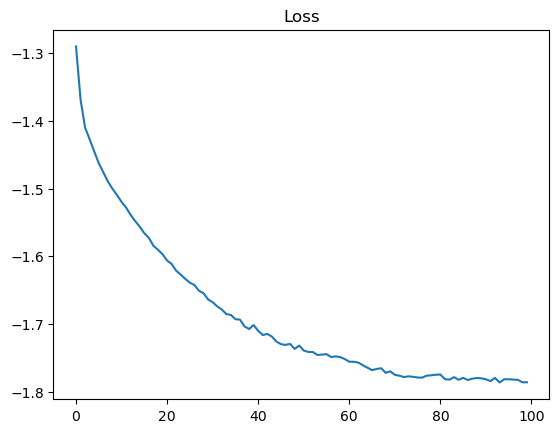

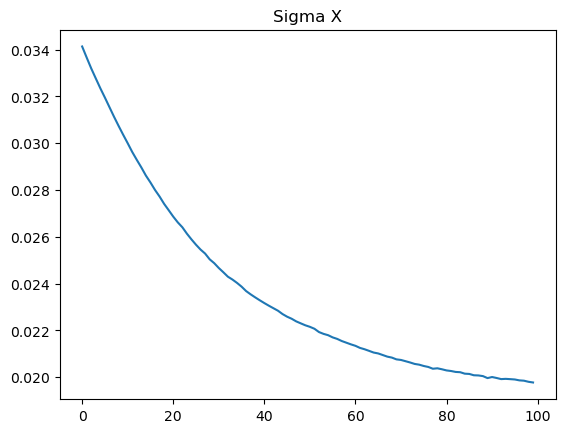

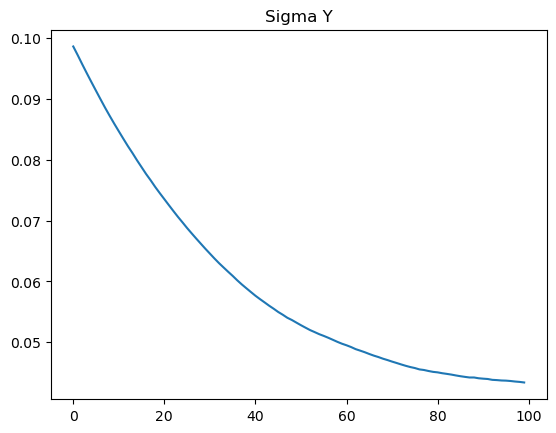

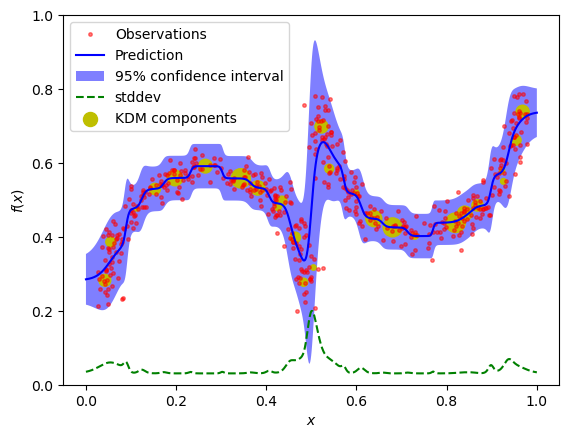

Test MSE: 0.00426
X_sigma / sqrt(2): 0.01398
Y_sigma / sqrt(2): 0.03068
Avg variance: 0.00264


In [5]:
kdm_disc_reg_model = train_model(n_comp=30, generative_weight=0.0, epochs=100)
plot_model(kdm_disc_reg_model)


Next, we train a generative KDM regression model with 30 components. The encoder is frozen and the loss adds `-w * log_marginal(rho_x)` so the support points are also pulled toward regions of high input density.


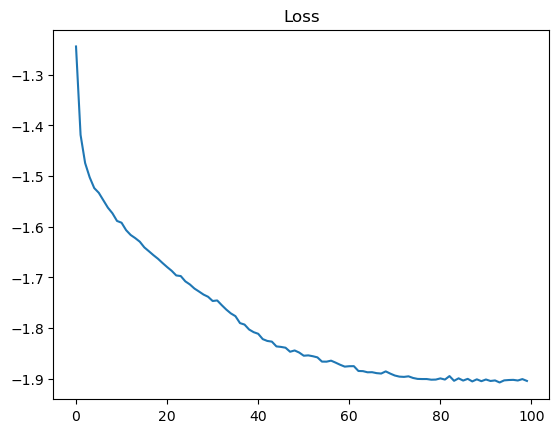

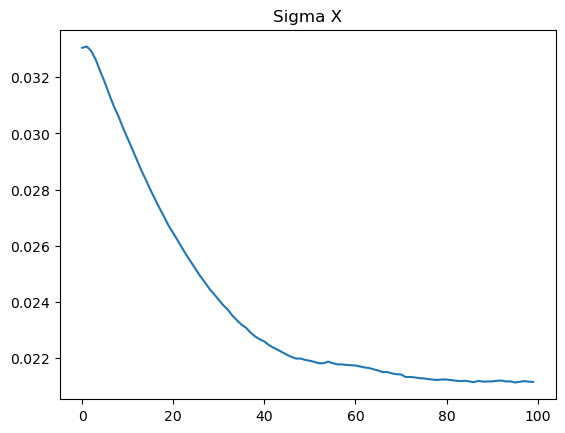

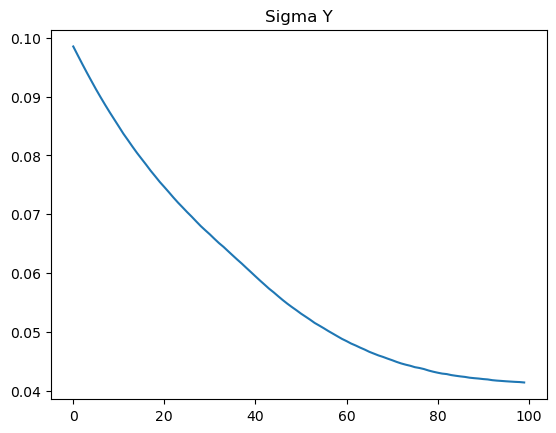

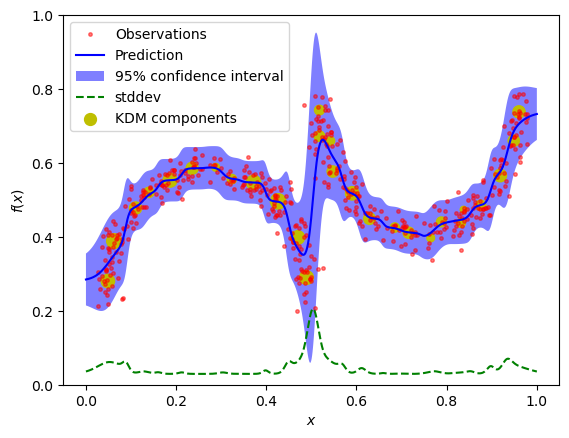

Test MSE: 0.00422
X_sigma / sqrt(2): 0.01496
Y_sigma / sqrt(2): 0.02926
Avg variance: 0.00276


In [6]:
kdm_gen_reg_model = train_model(n_comp=30, generative_weight=1.0, epochs=100)
plot_model(kdm_gen_reg_model)


The KDM models match or beat the GP in MSE while expressing a multimodal predictive distribution. We can read off the predictive density at any input via `dm_rbf_loglik`:


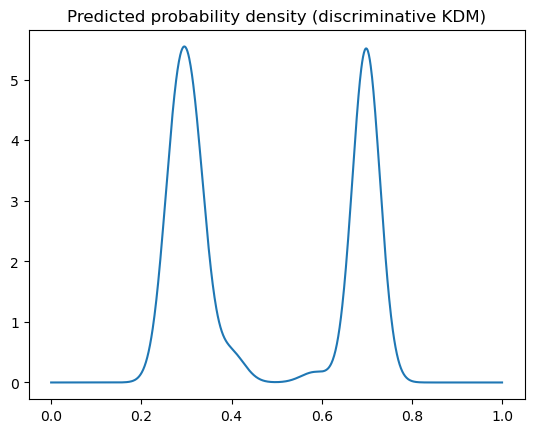

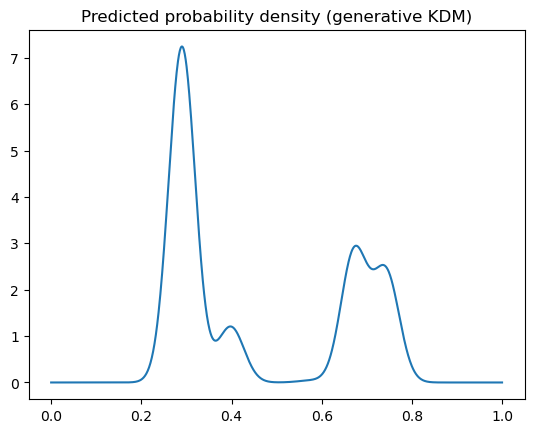

In [7]:
@torch.no_grad()
def predictive_density(model, x_query, y_grid):
    model.eval()
    rho_y = model(torch.as_tensor(x_query, dtype=torch.float32))
    log_p = dm_rbf_loglik(
        torch.as_tensor(y_grid, dtype=torch.float32), rho_y, model.sigma_y
    )
    return torch.exp(log_p).cpu().numpy()


for label, m in [("discriminative", kdm_disc_reg_model),
                 ("generative",      kdm_gen_reg_model)]:
    lik = predictive_density(m, np.array([[0.5]]), x_grid)
    plt.plot(x_grid, lik)
    plt.title(f"Predicted probability density ({label} KDM)")
    plt.show()


The plots clearly show the two modes of the data distribution at `x = 0.5`.


In [8]:
from kdm.utils import dm2comp

with torch.no_grad():
    rho_y = kdm_disc_reg_model(torch.as_tensor([[10.0]], dtype=torch.float32))
    w, _ = dm2comp(rho_y)
    print(f"Sum of weights at far-out-of-distribution input: {w.sum().item():.4f}")


Sum of weights at far-out-of-distribution input: 1.0000
